In [6]:
import numpy as np
import pandas as pd
import os

In [7]:
origin_folder = "generated_data_final/"
destination_folder = "generated_data_final_added/"

for folder in os.listdir(origin_folder):
    for subfolder in os.listdir(origin_folder+folder):
        destination_path = destination_folder+folder+"/"+subfolder+"/"
        origin_path = origin_folder+folder+"/"+subfolder+"/"
        for file in os.listdir(origin_path):
            print(origin_path+file)
            df = pd.read_csv(origin_path+file, delimiter=";")

            exp_charges = df[[col for col in df.columns if col.startswith("Exp_Charge__R")]]
            cur_charges = df[["Cur_Charge_R"+(col.split("__R")[-1]) for col in exp_charges.columns]]
            
            one = cur_charges.div(cur_charges.min(axis=1), axis=0).fillna(1).replace(np.inf, 100).rename(columns=dict(zip(cur_charges.columns,[col.replace("_R", "_comparable_R") for col in cur_charges.columns])))
            two = exp_charges.div(exp_charges.min(axis=1), axis=0).fillna(1).replace(np.inf, 100).rename(columns=dict(zip(exp_charges.columns,[col.replace("_R", "_comparable_R") for col in exp_charges.columns])))
            added = pd.concat([one,two], axis=1)
            
            ordered_columns = [col for col in df.columns if not col.startswith("Selected")] + list(added.columns) + [col for col in df.columns if col.startswith("Selected")]
            new_df = pd.concat([df,added], axis=1).loc[:,ordered_columns]

            new_df.to_csv(destination_path+file, sep=";", index=None)


generated_data_final/g2/multilabel/multilabel_data_scymetrie_s10_cell_1.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s10_cell_2.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s10_cell_3.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s10_cell_4.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s10_cell_5.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s11_cell_1.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s11_cell_2.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s11_cell_3.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s11_cell_4.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s11_cell_5.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s12_cell_1.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s12_cell_2.csv
generated_data_final/g2/multilabel/multilabel_data_scymetrie_s12_cell_3.csv
generated_da

### entrainements et simulations partielles

In [8]:
import numpy as np
import pandas as pd
import os
import pickle
import json
import systeme as sys
import Allocation
from simulation import simulation
import random
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import optuna
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, make_scorer, hamming_loss
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator
from functools import partial

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

instance_name = "G"

In [13]:
if instance_name != "G":
    print("calcul_gap defined on K")
    def calcul_gap(modele, scaler, cellule, scenarios):
        scenarios_path = f"scenarios/K0"
        solution_path = f"solution/K0_best//"
        
        with open(f'fms/3C7R5F.json', 'r') as json_file: #5C14R5F #3C7R5F
            dic = json.load(json_file)
        s = sys.systeme(dic)
        all_gaps = []
        for f in os.listdir(scenarios_path):
            if int(f.split(".")[0][1:]) not in scenarios:
                continue
            df = pd.DataFrame(np.nan_to_num(pd.read_csv(f"{scenarios_path}/"+f,header=None, index_col=None, sep=";"), nan=0)).astype(int)
            own_sol_path_list = [file for file in os.listdir(solution_path) if file.split(".")[0][-len(f.split(".")[0]):] == f.split(".")[0]]
            if len(own_sol_path_list) == 0:
                continue
            sol_path = own_sol_path_list[0]
            sol = pd.read_csv(solution_path+sol_path, sep=";", index_col=None, header=None).iloc[:,1:-1]

            allocators = [Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol)]
            ref_mct = simulation(system=s, scenario=df, allocators=allocators).mean_completion_time()
            allocators[cellule-1] = Allocation.DynamicAllocator(s, modele, scaler, to_categorical=True)
            mct = simulation(system=s, scenario=df, allocators=allocators).mean_completion_time()
            gap = (100*(mct - ref_mct)/ref_mct)
            all_gaps.append(gap)

        return np.mean(all_gaps)
else :
    print("calcul_gap defined on G")
    def calcul_gap(modele, scaler, cellule, scenarios):
        scenarios_path = f"scenarios/g3"
        solution_path = f"solution/g3_best//"
        
        with open(f'fms/5C14R5F.json', 'r') as json_file: #5C14R5F #3C7R5F
            dic = json.load(json_file)
        s = sys.systeme(dic)
        all_gaps = []
        for f in os.listdir(scenarios_path):
            df = pd.DataFrame(np.nan_to_num(pd.read_csv(f"{scenarios_path}/"+f,header=None, index_col=None, sep=";"), nan=0)).astype(int)
            own_sol_path_list = [file for file in os.listdir(solution_path) if file.split(".")[0][-len(f.split(".")[0]):] == f.split(".")[0]]
            if len(own_sol_path_list) == 0:
                continue
            sol_path = own_sol_path_list[0]
            sol = pd.read_csv(solution_path+sol_path, sep=";", index_col=None, header=None).iloc[:,1:-1]

            allocators = [Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol)]
            ref_mct = simulation(system=s, scenario=df, allocators=allocators).mean_completion_time()
            allocators[cellule-1] = Allocation.DynamicAllocator(s, modele, scaler, to_categorical=True)
            mct = simulation(system=s, scenario=df, allocators=allocators).mean_completion_time()
            gap = (100*(mct - ref_mct)/ref_mct)
            all_gaps.append(gap)

        return np.mean(all_gaps)

def callback(_, trial, cell, X_train, Y_train, scaler, scenarios_test, scores, cv):
    current_params = trial.params
    current_model = RandomForestClassifier(**current_params, random_state=RANDOM_SEED)
    current_model.fit(X_train, Y_train)

    current_gap = calcul_gap(current_model, scaler, cell, scenarios_test)
    acc = cross_val_score(current_model, X_train, Y_train, cv=cv, scoring=make_scorer(element_wise_accuracy_rf)).mean()
    scores.append([current_gap, acc])
    

def plot_convergence(study, scores):
    gaps = [score[0] for score in scores]
    accs = [score[1] for score in scores]

    cumulative_max = np.minimum.accumulate(gaps)  # Best mct

    plt.figure(figsize=(20, 6))  # Augmentation de la largeur pour le troisième subplot

    # Subplot 1 : Évolution de mct
    plt.subplot(1, 3, 1)
    plt.plot(gaps, label="mct", marker="o")
    plt.plot(cumulative_max, label="Best mct", color="orange", linestyle="dashed", marker="x")
    plt.title("Évolution de MCT lors du tuning")
    plt.xlabel("Essais (Trials)")
    plt.ylabel("Moyenne MCT")
    plt.grid()
    plt.legend()

    # Récupération des valeurs de accuracy
    cumulative_max_accuracy = np.maximum.accumulate(accs)

    # Subplot 2 : Évolution de accuracy
    plt.subplot(1, 3, 2)
    plt.plot(accs, label="accuracy", marker="o")
    plt.plot(cumulative_max_accuracy, label="Best accuracy", color="orange", linestyle="dashed", marker="x")
    plt.title("Évolution de l'accuracy lors du tuning")
    plt.xlabel("Essais (Trials)")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.legend()

    # Subplot 3 : Nuage de points MCT vs Accuracy
    plt.subplot(1, 3, 3)
    plt.scatter(accs, gaps, color="blue", alpha=0.6)
    plt.title("Relation entre MCT et Accuracy")
    plt.xlabel("Accuracy")
    plt.ylabel("MCT")
    plt.grid()

    plt.tight_layout()
    plt.show()

def element_wise_accuracy_rf(y_true, y_pred):
    # Convertir en numpy array pour éviter les conflits avec pandas
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float((y_true == y_pred).mean())

def objective_rf(trial, X_train, y_train, cv=3, scenarios_test=None, scaler=None, cell=None):
    """
    Fonction objectif pour optimiser les hyperparamètres d'un Random Forest avec Optuna.
    """
    # Définir les hyperparamètres à optimiser
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Initialiser le modèle avec les hyperparamètres
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_SEED
    )

    # Effectuer une validation croisée pour évaluer la performance

    model.fit(X_train, y_train)

    return  -calcul_gap(model, scaler, cell, scenarios_test)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=make_scorer(element_wise_accuracy_rf))
    return scores.mean()  # Retourner la moyenne des scores comme métrique

def train_random_forest_with_optuna(X_train, y_train, X_test, y_test, scaler, max_trials=1000, alpha=100, beta=0.1, patience_limit=5, random_seed=RANDOM_SEED, cell=1, scenarios_test=[]):
    """
    Entraîner un Random Forest optimisé via une recherche bayésienne sur les hyperparamètres.
    """
    # Initialiser une étude Optuna
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=random_seed))
    total_trials = 0
    remaining_trials = alpha  # Nombre initial de trials
    step = 0
    best_known_score = 0
    patience = 0
    scores = []

    custom_callback = partial(callback, X_train=X_train, Y_train=y_train, scenarios_test=scenarios_test, scores=scores, cell=cell, scaler=scaler, cv=3)

    while total_trials < max_trials and patience < patience_limit:
        print(f"Optimizing: Step {step + 1}, Remaining trials: {remaining_trials}")
        study.optimize(lambda trial: objective_rf(trial, X_train, y_train, cv=3, scenarios_test=scenarios_test, scaler=scaler, cell=cell), n_trials=remaining_trials, callbacks=[custom_callback])
        
        remaining_trials = int(np.ceil(alpha / (1 + beta * step)))
        total_trials += remaining_trials
        step += 1

        best_current_score = study.best_value

        if best_current_score > best_known_score:
            best_known_score = best_current_score
            patience = 0 
        else:
            patience += 1  # Augmenter la patience

    # Afficher les meilleurs paramètres trouvés
    best_params = study.best_params
    print(f"Best Hyperparameters: {best_params}")

    # Entraîner le modèle avec les meilleurs hyperparamètres
    model = RandomForestClassifier(**best_params, random_state=random_seed)
    model.fit(X_train, y_train)

    # Prédire sur le jeu de test et afficher les performances
    predictions = model.predict(X_test)
    print("Optimized Random Forest - Classification Report:")
    print(classification_report(y_test, predictions))

    plot_convergence(study, scores)

    return model, best_params

def element_wise_accuracy_xgb(y_true, y_pred):
    """
    Calculer l'accuracy élément par élément pour XGBoost.
    """
    y_pred_binary = np.round(y_pred)  # Convertir les probabilités en 0/1
    return np.mean(y_true == y_pred_binary)

def objective_xgb(trial, X_train, y_train, cv=3):
    """
    Fonction objectif pour optimiser les hyperparamètres d'un XGBoost avec Optuna.
    """
    # Définir les hyperparamètres à optimiser
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 15)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    gamma = trial.suggest_float("gamma", 0, 10)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    
    # Initialiser le modèle avec les hyperparamètres
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        min_child_weight=min_child_weight,
        eval_metric="mlogloss",
        random_state=42
    )

    # Utiliser une métrique personnalisée pour la validation croisée
    scorer = make_scorer(element_wise_accuracy_xgb, greater_is_better=True)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=scorer)
    return scores.mean()  # Retourner la moyenne des scores comme métrique

def train_xgboost_with_optuna(X_train, y_train, X_test, y_test, max_trials=1000, alpha=100, beta=0.1, patience_limit=5, random_seed=RANDOM_SEED):
    """
    Entraîner un XGBoost optimisé via une recherche bayésienne sur les hyperparamètres.
    Le nombre de trials est ajusté dynamiquement.
    """
    # Initialisation des variables pour les trials dynamiques
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=random_seed))
    total_trials = 0
    remaining_trials = alpha  # Nombre initial de trials
    step = 0
    best_known_score = 0
    patience = 0

    while total_trials < max_trials and patience < patience_limit:
        print(f"Optimizing: Step {step + 1}, Remaining trials: {remaining_trials}")
        study.optimize(lambda trial: objective_xgb(trial, X_train, y_train), n_trials=remaining_trials)

        remaining_trials = int(np.ceil(alpha / (1 + beta * step)))
        total_trials += remaining_trials
        step += 1

        best_current_score = study.best_value

        if best_current_score > best_known_score:
            best_known_score = best_current_score
            patience = 0 
        else:
            patience += 1  # Augmenter la patience

    # Afficher les meilleurs paramètres trouvés
    best_params = study.best_params
    print(f"Best Hyperparameters: {best_params}")

    # Entraîner le modèle avec les meilleurs hyperparamètres
    model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric="mlogloss", random_state=random_seed)
    model.fit(X_train, y_train)

    # Prédire sur le jeu de test et afficher les performances
    predictions = model.predict(X_test)
    predictions_binary = np.round(predictions)  # Convertir les probabilités en 0/1 si nécessaire
    print("Optimized XGBoost - Classification Report:")
    print(classification_report(y_test, predictions_binary))

    # Graphe de convergence
    plot_convergence(study, step, final=True)

    return model, best_params

def element_wise_accuracy_nn(y_true, y_pred):
    """
    Calcul de l'accuracy élément par élément pour les problèmes multilabels.
    """
    y_pred_binary = K.round(y_pred)  # Convertir les probabilités en 0/1
    y_true = K.cast(y_true, dtype='float32')  # Convertir y_true en float32 pour correspondre à y_pred_binary
    return K.mean(K.cast(K.equal(y_true, y_pred_binary), dtype='float32'))

def objective_nn(trial, X_train, y_train, X_test, y_test, num_classes, epochs=20, batch_size=32):
    """
    Fonction objectif pour optimiser les hyperparamètres d'un réseau de neurones avec Optuna.
    """
    # Hyperparamètres à optimiser
    num_layers = trial.suggest_int("num_layers", 1, 3)
    units = trial.suggest_int("units", 16, 256)
    dropout_rate = trial.suggest_float("dropout_rate", 0.05, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    # Construction du modèle
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(units, activation='relu'))
    model.add(Dropout(dropout_rate))
    for _ in range(num_layers - 1):
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='sigmoid'))  # Activation sigmoid pour les problèmes multilabels

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Loss adaptée pour du multilabel
                  metrics=[element_wise_accuracy_nn])

    # Entraînement
    history = model.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=epochs, batch_size=batch_size,
                        verbose=0)
    val_accuracy = max(history.history['val_element_wise_accuracy_nn'])  # Acc élément par élément
    return val_accuracy

def train_neural_network_with_optuna(X_train, y_train, X_test, y_test, 
                                             max_trials=1000, alpha=100, beta=0.1, patience_limit=5, 
                                             random_seed=RANDOM_SEED, epochs=20, batch_size=32):
    """
    Entraîner un réseau de neurones optimisé avec un nombre dynamique de trials et tracer le graphe de convergence.
    """
    np.random.seed(random_seed)
    num_classes = y_train.shape[1]

    # Initialiser une étude Optuna
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=random_seed))

    total_trials = 0
    remaining_trials = alpha
    step = 0
    best_known_score = 0
    patience = 0

    while total_trials < max_trials and patience < patience_limit:
        print(f"Optimizing: Step {step + 1}, Remaining trials: {remaining_trials}")
        study.optimize(lambda trial: objective_nn(trial, X_train, y_train, X_test, y_test, num_classes, epochs, batch_size),
                       n_trials=remaining_trials)

        # Calculer le nombre de nouveaux trials à ajouter
        remaining_trials = int(np.ceil(alpha / (1 + beta * step)))
        total_trials += remaining_trials
        step += 1

        # Détection de convergence (aucune amélioration significative)
        best_current_score = study.best_value

        if best_current_score > best_known_score:
            best_known_score = best_current_score
            patience = 0 
        else:
            patience += 1  # Augmenter la patience
            
    # Afficher les meilleurs paramètres
    best_params = study.best_params
    print(f"Best Hyperparameters: {best_params}")

    # Construire et entraîner le modèle final
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(best_params['units'], activation='relu'))
    model.add(Dropout(best_params['dropout_rate']))
    for _ in range(best_params['num_layers'] - 1):
        model.add(Dense(best_params['units'], activation='relu'))
        model.add(Dropout(best_params['dropout_rate']))
    model.add(Dense(num_classes, activation='sigmoid'))  # Activation sigmoid pour multilabel

    model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']),
                  loss='binary_crossentropy',
                  metrics=[element_wise_accuracy_nn])

    model.fit(X_train, y_train,
              validation_data=(X_test, y_test),
              epochs=epochs, batch_size=batch_size,
              verbose=1)

    # Évaluation finale
    predictions = model.predict(X_test)
    print("Optimized Neural Network - Classification Report:")
    print(classification_report(y_test, np.round(predictions)))

    # Graphe final de convergence
    plot_convergence(study, step, final=True)

    return model, best_params

calcul_gap defined on G


In [ ]:
#data preparation K0

standardisation = True
instance_name = "K0"
test_size = 30/100
data_folder_path = f"./generated_data_final_added/{instance_name}/multilabel/"

with open(f'fms/3C7R5F.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
s = sys.systeme(dic)

file_names_per_cell, columns_per_cell, dfs_train, dfs_test, scalers = [],[],[],[],[]

for cell,c in zip(s.cellules,range(len(s.cellules))):
    file_names_per_cell.append([file for file in os.listdir(data_folder_path) if file.endswith(f"cell_{c+1}.csv")])
    kept_cols = cell.header[:-1]
    columns_per_cell.append(kept_cols)
    
    if c == 0:
        test_split = list(range(1, len(file_names_per_cell[0])+1))
        random.shuffle(test_split)
        test_split = test_split[:int(len(file_names_per_cell[0])*test_size)]
        test_split_scenarios = test_split[:len(test_split)]
        train_split_scenarios = [file for file in list(range(1,len(file_names_per_cell[0])+1)) if file not in test_split]

    paths = sorted([data_folder_path+"/"+x for x in os.listdir(data_folder_path) if x.endswith(f"{c+1}.csv")], key= lambda k: int(k.split("_cell_")[0].split("s")[-1]))

    filtered_dfs_train = [pd.read_csv(paths[scenar-1], delimiter=";") for scenar in train_split_scenarios]
    filtered_dfs_test = [pd.read_csv(paths[scenar-1], delimiter=";") for scenar in test_split_scenarios]
    

    df_train = pd.concat(filtered_dfs_train, ignore_index=True)
    df_train.fillna(0, inplace=True)


    categorical_cols = [col for col in df_train.columns if col.startswith("predFamilies") or col.startswith("State") or col.startswith("Curn_Fam")]
    to_delete_cols = [col+"_0" for col in df_train.columns if col.startswith("predFamilies") or col.startswith("Curn_Fam")]  
    last_col = [col for col in df_train.columns if col.startswith("Selected")]
    categorical_spec = {
        "predFamilies": [1, 2, 3, 4, 5],
        "State": ["FREE", "SETUP", "WORKING"],
        "Curn_Fam": [-1, 1, 2, 3, 4, 5]
    }
    new_columns = []
    for prefix, unique_values in categorical_spec.items():
        cols_to_encode = [col for col in df_train.columns if col.startswith(prefix)]
        for col in cols_to_encode:
            for value in unique_values:
                new_col_name = f"{col}_{value}"
                new_columns.append(pd.DataFrame({new_col_name: (df_train[col] == value).astype(float)}))
    df_train = pd.concat([df_train] + new_columns, axis=1)       
    df_train.drop(columns=to_delete_cols, inplace=True, errors='ignore')
    df_train.drop(columns=categorical_cols, inplace=True, errors='ignore')

    colus = df_train.columns.tolist()
    for col in last_col:
        colus.remove(col)
        df_train = df_train[colus + [col]]
        colus.append(col)
    
    no_label_cols = [col for col in df_train.columns if not col.startswith("Selected")]
    label_cols = [col for col in df_train.columns if col.startswith("Selected")]
    
    if standardisation :
        scaler = StandardScaler()
        columns = df_train.columns
        df_train_scaled = pd.DataFrame(scaler.fit_transform(df_train[no_label_cols]), columns=no_label_cols)
        df_train_scaled[label_cols] = df_train[label_cols]
        df_train = df_train_scaled
        with open(f"generated_models/multiclass_added_min/K0/models_cell{c+1}/scaler.pkl", 'wb') as file:
            pickle.dump(scaler, file)
        scalers.append(scaler)
    dfs_train.append(df_train.astype(float))



    df_test = pd.concat(filtered_dfs_test, ignore_index=True)
    df_test.fillna(0, inplace=True)

    new_columns = []
    for prefix, unique_values in categorical_spec.items():
        cols_to_encode = [col for col in df_test.columns if col.startswith(prefix)]
        for col in cols_to_encode:
            for value in unique_values:
                new_col_name = f"{col}_{value}"
                new_columns.append(pd.DataFrame({new_col_name: (df_test[col] == value).astype(float)}))
    df_test = pd.concat([df_test] + new_columns, axis=1)
    df_test.drop(columns=to_delete_cols, inplace=True, errors='ignore')
    df_test.drop(columns=categorical_cols, inplace=True, errors='ignore')

    colus = df_test.columns.tolist()
    for col in last_col:
        colus.remove(col)
        df_test = df_test[colus + [col]]
        colus.append(col)

    if standardisation :
        columns = df_test.columns
        df_test_scaled = pd.DataFrame(scaler.transform(df_test[no_label_cols]), columns=no_label_cols)
        df_test_scaled[label_cols] = df_test[label_cols]
        df_test = df_test_scaled
    dfs_test.append(df_test.astype(float))


In [20]:
#data preparation G

standardisation = True
instance_name = "G"
data_folder_path_train = f"./generated_data_final_added/g2/multilabel/"  # Train
data_folder_path_test = f"./generated_data_final_added/g3/multilabel/"   # Test

# Charger le JSON de configuration
with open(f'fms/5C14R5F.json', 'r') as json_file:
    dic = json.load(json_file)
s = sys.systeme(dic)

file_names_per_cell, columns_per_cell, dfs_train, dfs_test, scalers = [],[],[],[],[]

for cell, c in zip(s.cellules, range(len(s.cellules))):
    file_names_per_cell.append([file for file in os.listdir(data_folder_path_train) if file.endswith(f"cell_{c+1}.csv")])
    kept_cols = cell.header[:-1]
    columns_per_cell.append(kept_cols)

    # Récupération des chemins des fichiers
    train_paths = sorted(
        [data_folder_path_train + x for x in os.listdir(data_folder_path_train) if x.endswith(f"{c+1}.csv")], 
        key=lambda k: int(k.split("_cell_")[0].split("s")[-1])
    )
    test_paths = sorted(
        [data_folder_path_test + x for x in os.listdir(data_folder_path_test) if x.endswith(f"{c+1}.csv")], 
        key=lambda k: int(k.split("_cell_")[0].split("s")[-1])
    )

    # Chargement des fichiers CSV
    filtered_dfs_train = [pd.read_csv(path, delimiter=";") for path in train_paths]
    filtered_dfs_test = [pd.read_csv(path, delimiter=";") for path in test_paths]

    df_train = pd.concat(filtered_dfs_train, ignore_index=True).fillna(0)
    df_test = pd.concat(filtered_dfs_test, ignore_index=True).fillna(0)

    # Encodage des colonnes catégoriques
    categorical_spec = {
        "predFamilies": [1, 2, 3, 4, 5],
        "State": ["FREE", "SETUP", "WORKING"],
        "Curn_Fam": [-1, 1, 2, 3, 4, 5]
    }
    categorical_cols = [col for col in df_train.columns if col.startswith(("predFamilies", "State", "Curn_Fam"))]
    to_delete_cols = [col+"_0" for col in categorical_cols]  
    last_col = [col for col in df_train.columns if col.startswith("Selected")]

    
    
    categorical_cols = [col for col in df_train.columns if col.startswith("predFamilies") or col.startswith("State") or col.startswith("Curn_Fam")]
    to_delete_cols = [col+"_0" for col in df_train.columns if col.startswith("predFamilies") or col.startswith("Curn_Fam")]  
    last_col = [col for col in df_train.columns if col.startswith("Selected")]
    categorical_spec = {
        "predFamilies": [1, 2, 3, 4, 5],
        "State": ["FREE", "SETUP", "WORKING"],
        "Curn_Fam": [-1, 1, 2, 3, 4, 5]
    }
    new_columns = []
    for prefix, unique_values in categorical_spec.items():
        cols_to_encode = [col for col in df_train.columns if col.startswith(prefix)]
        for col in cols_to_encode:
            for value in unique_values:
                new_col_name = f"{col}_{value}"
                new_columns.append(pd.DataFrame({new_col_name: (df_train[col] == value).astype(float)}))
    df_train = pd.concat([df_train] + new_columns, axis=1)       
    df_train.drop(columns=to_delete_cols, inplace=True, errors='ignore')
    df_train.drop(columns=categorical_cols, inplace=True, errors='ignore')

    new_columns = []
    for prefix, unique_values in categorical_spec.items():
        cols_to_encode = [col for col in df_test.columns if col.startswith(prefix)]
        for col in cols_to_encode:
            for value in unique_values:
                new_col_name = f"{col}_{value}"
                new_columns.append(pd.DataFrame({new_col_name: (df_test[col] == value).astype(float)}))
    df_test = pd.concat([df_test] + new_columns, axis=1)
    df_test.drop(columns=to_delete_cols, inplace=True, errors='ignore')
    df_test.drop(columns=categorical_cols, inplace=True, errors='ignore')


    # Réorganisation des colonnes
    colus = df_train.columns.tolist()
    for col in last_col:
        colus.remove(col)
        df_train = df_train[colus + [col]]
        colus.append(col)

    colus = df_test.columns.tolist()
    for col in last_col:
        colus.remove(col)
        df_test = df_test[colus + [col]]
        colus.append(col)

    # Standardisation si activée
    no_label_cols = [col for col in df_train.columns if not col.startswith("Selected")]
    label_cols = [col for col in df_train.columns if col.startswith("Selected")]

    if standardisation:
        scaler = StandardScaler()
        df_train_scaled = pd.DataFrame(scaler.fit_transform(df_train[no_label_cols]), columns=no_label_cols)
        df_train_scaled[label_cols] = df_train[label_cols]
        df_train = df_train_scaled

        with open(f"generated_models/multiclass_added_min/G/models_cell{c+1}/scaler.pkl", 'wb') as file:
            pickle.dump(scaler, file)

        scalers.append(scaler)

    dfs_train.append(df_train.astype(float))

    if standardisation:
        df_test_scaled = pd.DataFrame(scaler.transform(df_test[no_label_cols]), columns=no_label_cols)
        df_test_scaled[label_cols] = df_test[label_cols]
        df_test = df_test_scaled

    dfs_test.append(df_test.astype(float))

In [4]:
if instance_name == "G":
    test_split_scenarios = list(range(1,21))
test_split_scenarios # only K0

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

[I 2025-03-15 09:43:07,200] A new study created in memory with name: no-name-204fd94c-310e-42d0-9ee4-cbc9353353bf



Processing dataset 1...

Number of ressources 2...
Optimizing: Step 1, Remaining trials: 100


[I 2025-03-15 09:43:48,556] Trial 0 finished with value: -22.773710460060244 and parameters: {'n_estimators': 144, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 0 with value: -22.773710460060244.
[I 2025-03-15 09:45:15,470] Trial 1 finished with value: -23.378571134617406 and parameters: {'n_estimators': 267, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: -22.773710460060244.
[I 2025-03-15 09:46:42,612] Trial 2 finished with value: -30.259498263502746 and parameters: {'n_estimators': 95, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 11, 'max_features': None}. Best is trial 0 with value: -22.773710460060244.
[I 2025-03-15 09:48:05,902] Trial 3 finished with value: -22.33369797855423 and parameters: {'n_estimators': 85, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 3 with value: -22.3336979

Optimizing: Step 2, Remaining trials: 100


[I 2025-03-15 12:10:25,076] Trial 100 finished with value: -34.41360225390288 and parameters: {'n_estimators': 296, 'max_depth': 5, 'min_samples_split': 17, 'min_samples_leaf': 18, 'max_features': None}. Best is trial 91 with value: -21.079644832653123.
[I 2025-03-15 12:12:05,992] Trial 101 finished with value: -22.358059611194637 and parameters: {'n_estimators': 288, 'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 11, 'max_features': 'sqrt'}. Best is trial 91 with value: -21.079644832653123.
[I 2025-03-15 12:13:35,049] Trial 102 finished with value: -22.26923234298422 and parameters: {'n_estimators': 281, 'max_depth': 3, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 91 with value: -21.079644832653123.
[I 2025-03-15 12:15:00,496] Trial 103 finished with value: -22.118195895980154 and parameters: {'n_estimators': 147, 'max_depth': 2, 'min_samples_split': 15, 'min_samples_leaf': 11, 'max_features': 'sqrt'}. Best is trial 91 with value

...

Optimizing: Step 4, Remaining trials: 84


[I 2025-03-15 16:48:23,835] Trial 291 finished with value: -22.121130897866955 and parameters: {'n_estimators': 243, 'max_depth': 2, 'min_samples_split': 16, 'min_samples_leaf': 13, 'max_features': 'sqrt'}. Best is trial 184 with value: -20.86619507070973.
[I 2025-03-15 16:49:48,601] Trial 292 finished with value: -22.030935621340355 and parameters: {'n_estimators': 228, 'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 13, 'max_features': 'sqrt'}. Best is trial 184 with value: -20.86619507070973.
[I 2025-03-15 16:51:13,284] Trial 293 finished with value: -21.27447315000077 and parameters: {'n_estimators': 201, 'max_depth': 3, 'min_samples_split': 17, 'min_samples_leaf': 14, 'max_features': 'sqrt'}. Best is trial 184 with value: -20.86619507070973.
[I 2025-03-15 16:52:37,362] Trial 294 finished with value: -22.51232556290006 and parameters: {'n_estimators': 181, 'max_depth': 4, 'min_samples_split': 15, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 184 with v

Optimizing: Step 5, Remaining trials: 77


[I 2025-03-15 18:50:15,712] Trial 375 finished with value: -21.181967041695504 and parameters: {'n_estimators': 266, 'max_depth': 3, 'min_samples_split': 16, 'min_samples_leaf': 13, 'max_features': 'sqrt'}. Best is trial 184 with value: -20.86619507070973.
[I 2025-03-15 18:51:40,050] Trial 376 finished with value: -43.813950060631115 and parameters: {'n_estimators': 81, 'max_depth': 4, 'min_samples_split': 15, 'min_samples_leaf': 14, 'max_features': None}. Best is trial 184 with value: -20.86619507070973.
[I 2025-03-15 18:53:05,514] Trial 377 finished with value: -21.44646281169622 and parameters: {'n_estimators': 254, 'max_depth': 3, 'min_samples_split': 17, 'min_samples_leaf': 13, 'max_features': 'sqrt'}. Best is trial 184 with value: -20.86619507070973.
[I 2025-03-15 18:54:32,837] Trial 378 finished with value: -22.383805783343227 and parameters: {'n_estimators': 260, 'max_depth': 2, 'min_samples_split': 17, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 184 with val

Best Hyperparameters: {'n_estimators': 247, 'max_depth': 3, 'min_samples_split': 17, 'min_samples_leaf': 13, 'max_features': 'sqrt'}
Optimized Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.67      0.70      1016
           1       0.68      0.82      0.74      1006

   micro avg       0.71      0.74      0.72      2022
   macro avg       0.71      0.74      0.72      2022
weighted avg       0.71      0.74      0.72      2022
 samples avg       0.72      0.74      0.72      2022



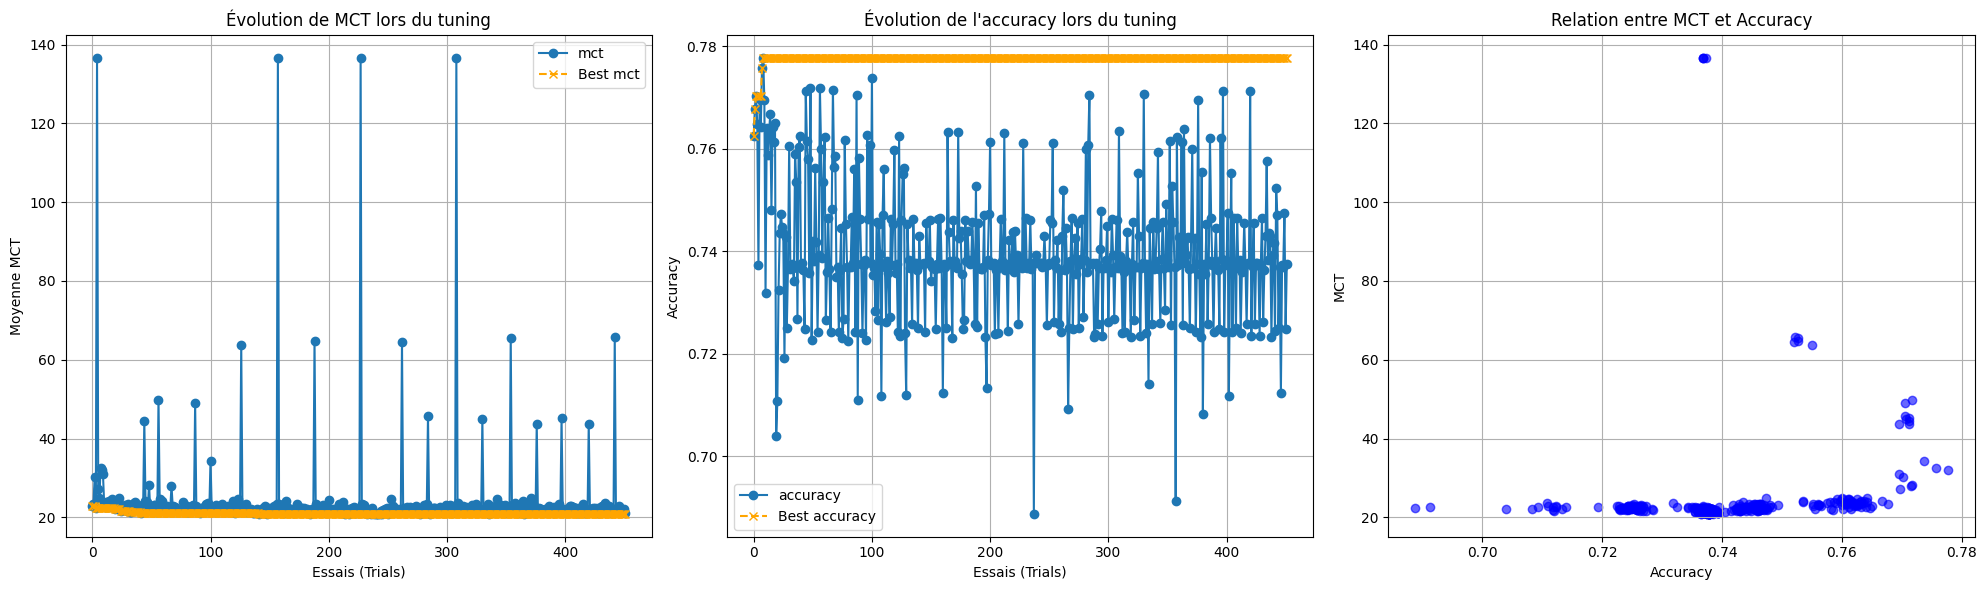

[I 2025-03-15 20:41:33,719] A new study created in memory with name: no-name-9e3c89a7-5f34-4b1b-abd7-2936beea726f


Validation Performance for dataset 1:
              precision    recall  f1-score   support

           0       0.74      0.67      0.70      1016
           1       0.68      0.82      0.74      1006

   micro avg       0.71      0.74      0.72      2022
   macro avg       0.71      0.74      0.72      2022
weighted avg       0.71      0.74      0.72      2022
 samples avg       0.72      0.74      0.72      2022

(2000, 2) (2000, 2)
Accuracy: 0.71475
Hamming Score: 0.71475
calculated accuracy based on top probability only:0.7155
- - - saving - - -

Processing dataset 2...

Number of ressources 3...
Optimizing: Step 1, Remaining trials: 100


[I 2025-03-15 20:42:18,690] Trial 0 finished with value: -37.89748338328407 and parameters: {'n_estimators': 144, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 0 with value: -37.89748338328407.
[I 2025-03-15 20:43:52,974] Trial 1 finished with value: -39.44976884508129 and parameters: {'n_estimators': 267, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: -37.89748338328407.
[I 2025-03-15 20:45:29,353] Trial 2 finished with value: -178.05918127851163 and parameters: {'n_estimators': 95, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 11, 'max_features': None}. Best is trial 0 with value: -37.89748338328407.
[I 2025-03-15 20:47:01,671] Trial 3 finished with value: -37.87837911989891 and parameters: {'n_estimators': 85, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 3 with value: -37.878379119898

Optimizing: Step 2, Remaining trials: 100


[I 2025-03-15 23:24:54,294] Trial 100 finished with value: -33.292765629724094 and parameters: {'n_estimators': 229, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 94 with value: -31.63036792816938.
[I 2025-03-15 23:26:51,701] Trial 101 finished with value: -32.483727343479394 and parameters: {'n_estimators': 85, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 94 with value: -31.63036792816938.
[I 2025-03-15 23:28:29,831] Trial 102 finished with value: -36.50178786405256 and parameters: {'n_estimators': 103, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 94 with value: -31.63036792816938.
[I 2025-03-15 23:30:09,223] Trial 103 finished with value: -31.41417188181316 and parameters: {'n_estimators': 92, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 103 with value: -31.4141718

...

Optimizing: Step 4, Remaining trials: 84


[I 2025-03-16 04:50:37,800] Trial 291 finished with value: -31.110165285422035 and parameters: {'n_estimators': 115, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 196 with value: -30.739335797528373.
[I 2025-03-16 04:52:21,016] Trial 292 finished with value: -31.246344462743412 and parameters: {'n_estimators': 117, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 196 with value: -30.739335797528373.
[I 2025-03-16 04:54:04,786] Trial 293 finished with value: -32.3816659035393 and parameters: {'n_estimators': 122, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 196 with value: -30.739335797528373.
[I 2025-03-16 04:55:48,433] Trial 294 finished with value: -31.110165285422035 and parameters: {'n_estimators': 115, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 196 with value: -30

Optimizing: Step 5, Remaining trials: 77


[I 2025-03-16 07:15:12,656] Trial 375 finished with value: -30.8265046944601 and parameters: {'n_estimators': 119, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 196 with value: -30.739335797528373.
[I 2025-03-16 07:16:56,841] Trial 376 finished with value: -33.46822638611785 and parameters: {'n_estimators': 129, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 196 with value: -30.739335797528373.
[I 2025-03-16 07:18:41,935] Trial 377 finished with value: -35.341963613748675 and parameters: {'n_estimators': 122, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 196 with value: -30.739335797528373.
[I 2025-03-16 07:20:25,712] Trial 378 finished with value: -32.108012625821054 and parameters: {'n_estimators': 119, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 196 with value: -30.

Best Hyperparameters: {'n_estimators': 118, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': None}
Optimized Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.64      0.68       845
           1       0.72      0.56      0.63       707
           2       0.65      0.54      0.59       584

   micro avg       0.71      0.59      0.64      2136
   macro avg       0.70      0.58      0.63      2136
weighted avg       0.71      0.59      0.64      2136
 samples avg       0.63      0.60      0.61      2136



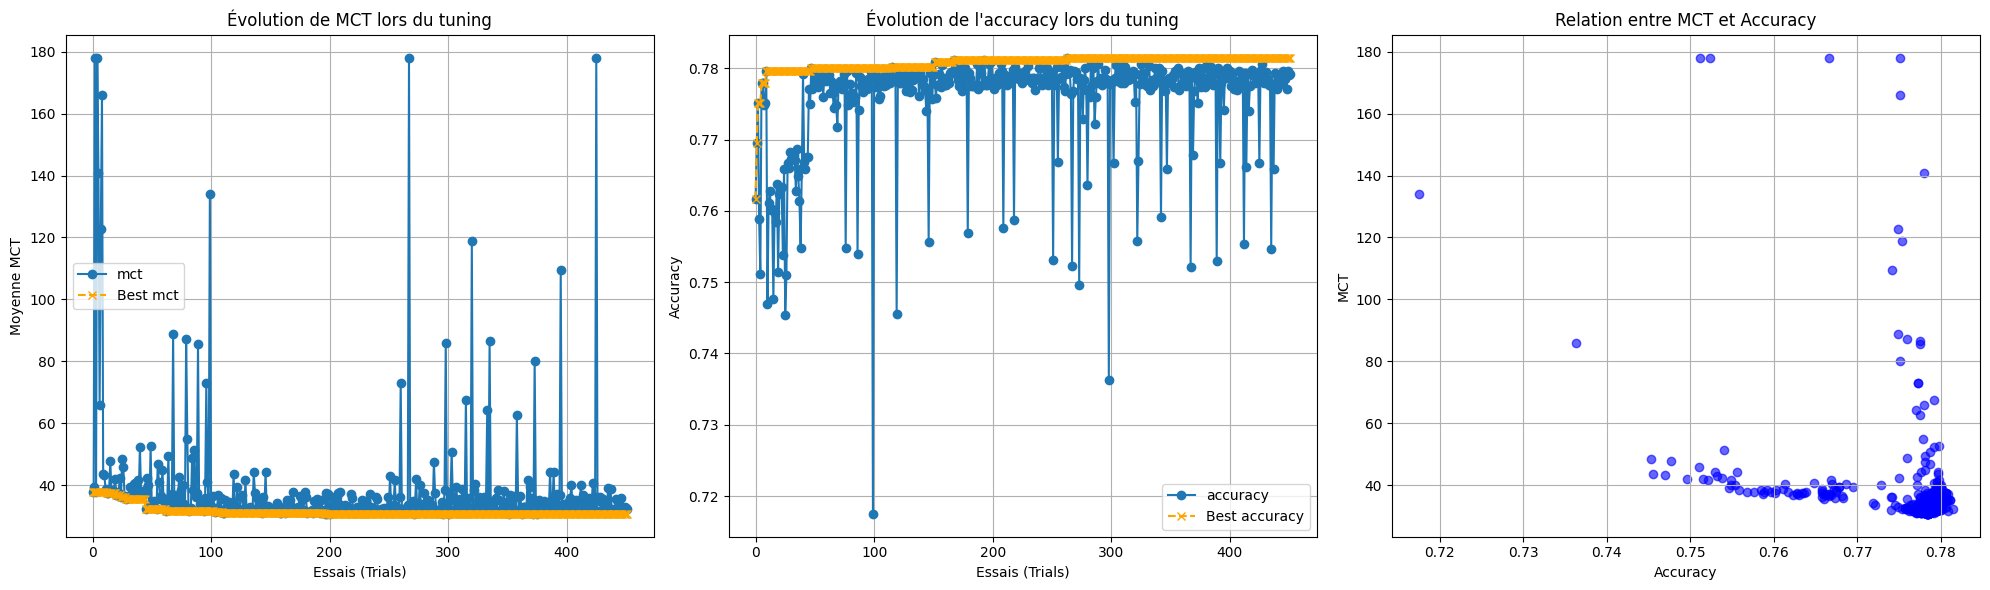

[I 2025-03-16 09:25:28,035] A new study created in memory with name: no-name-d871fceb-2036-4163-ab48-5a2c297b8059


Validation Performance for dataset 2:
              precision    recall  f1-score   support

           0       0.73      0.64      0.68       845
           1       0.72      0.56      0.63       707
           2       0.65      0.54      0.59       584

   micro avg       0.71      0.59      0.64      2136
   macro avg       0.70      0.58      0.63      2136
weighted avg       0.71      0.59      0.64      2136
 samples avg       0.63      0.60      0.61      2136

(2000, 3) (2000, 3)
Accuracy: 0.7661666666666667
Hamming Score: 0.7661666666666667
calculated accuracy based on top probability only:0.6805
- - - saving - - -

Processing dataset 3...

Number of ressources 4...
Optimizing: Step 1, Remaining trials: 100


[I 2025-03-16 09:26:16,558] Trial 0 finished with value: -103.87720015138026 and parameters: {'n_estimators': 144, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 0 with value: -103.87720015138026.
[I 2025-03-16 09:27:58,340] Trial 1 finished with value: -103.87720015138026 and parameters: {'n_estimators': 267, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: -103.87720015138026.
[I 2025-03-16 09:29:41,170] Trial 2 finished with value: -103.87720015138026 and parameters: {'n_estimators': 95, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 11, 'max_features': None}. Best is trial 0 with value: -103.87720015138026.
[I 2025-03-16 09:31:19,994] Trial 3 finished with value: -103.87720015138026 and parameters: {'n_estimators': 85, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: -103.87720

Optimizing: Step 2, Remaining trials: 100


[I 2025-03-16 12:20:19,251] Trial 100 finished with value: -88.47476814965727 and parameters: {'n_estimators': 134, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 98 with value: -20.185225186437314.
[I 2025-03-16 12:21:56,716] Trial 101 finished with value: -45.93249840843034 and parameters: {'n_estimators': 156, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 98 with value: -20.185225186437314.
[I 2025-03-16 12:23:34,329] Trial 102 finished with value: -83.29739004096157 and parameters: {'n_estimators': 141, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 98 with value: -20.185225186437314.
[I 2025-03-16 12:25:11,043] Trial 103 finished with value: -59.192409281801346 and parameters: {'n_estimators': 131, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 98 with value: 

...

Optimizing: Step 4, Remaining trials: 84


[I 2025-03-16 17:25:23,365] Trial 291 finished with value: -80.97952191345085 and parameters: {'n_estimators': 121, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 152 with value: -16.293148390070492.
[I 2025-03-16 17:26:59,218] Trial 292 finished with value: -103.87720015138026 and parameters: {'n_estimators': 132, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_features': 'log2'}. Best is trial 152 with value: -16.293148390070492.
[I 2025-03-16 17:28:33,728] Trial 293 finished with value: -58.63994741143987 and parameters: {'n_estimators': 74, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 152 with value: -16.293148390070492.
[I 2025-03-16 17:30:07,829] Trial 294 finished with value: -23.852465042902544 and parameters: {'n_estimators': 127, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 152 with va

Optimizing: Step 5, Remaining trials: 77


[I 2025-03-16 19:35:39,188] Trial 375 finished with value: -55.13544345455962 and parameters: {'n_estimators': 67, 'max_depth': 18, 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 342 with value: -13.140187973880831.
[I 2025-03-16 19:37:11,717] Trial 376 finished with value: -93.6629765832889 and parameters: {'n_estimators': 72, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 342 with value: -13.140187973880831.
[I 2025-03-16 19:38:44,009] Trial 377 finished with value: -13.140187973880831 and parameters: {'n_estimators': 77, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 342 with value: -13.140187973880831.
[I 2025-03-16 19:40:16,687] Trial 378 finished with value: -16.171376206715316 and parameters: {'n_estimators': 78, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 342 with value:

Best Hyperparameters: {'n_estimators': 77, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}
Optimized Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       832
           1       0.85      0.56      0.68       588
           2       0.84      0.55      0.67       431
           3       0.85      0.45      0.59       329

   micro avg       0.81      0.63      0.71      2180
   macro avg       0.83      0.59      0.68      2180
weighted avg       0.82      0.63      0.70      2180
 samples avg       0.69      0.66      0.67      2180



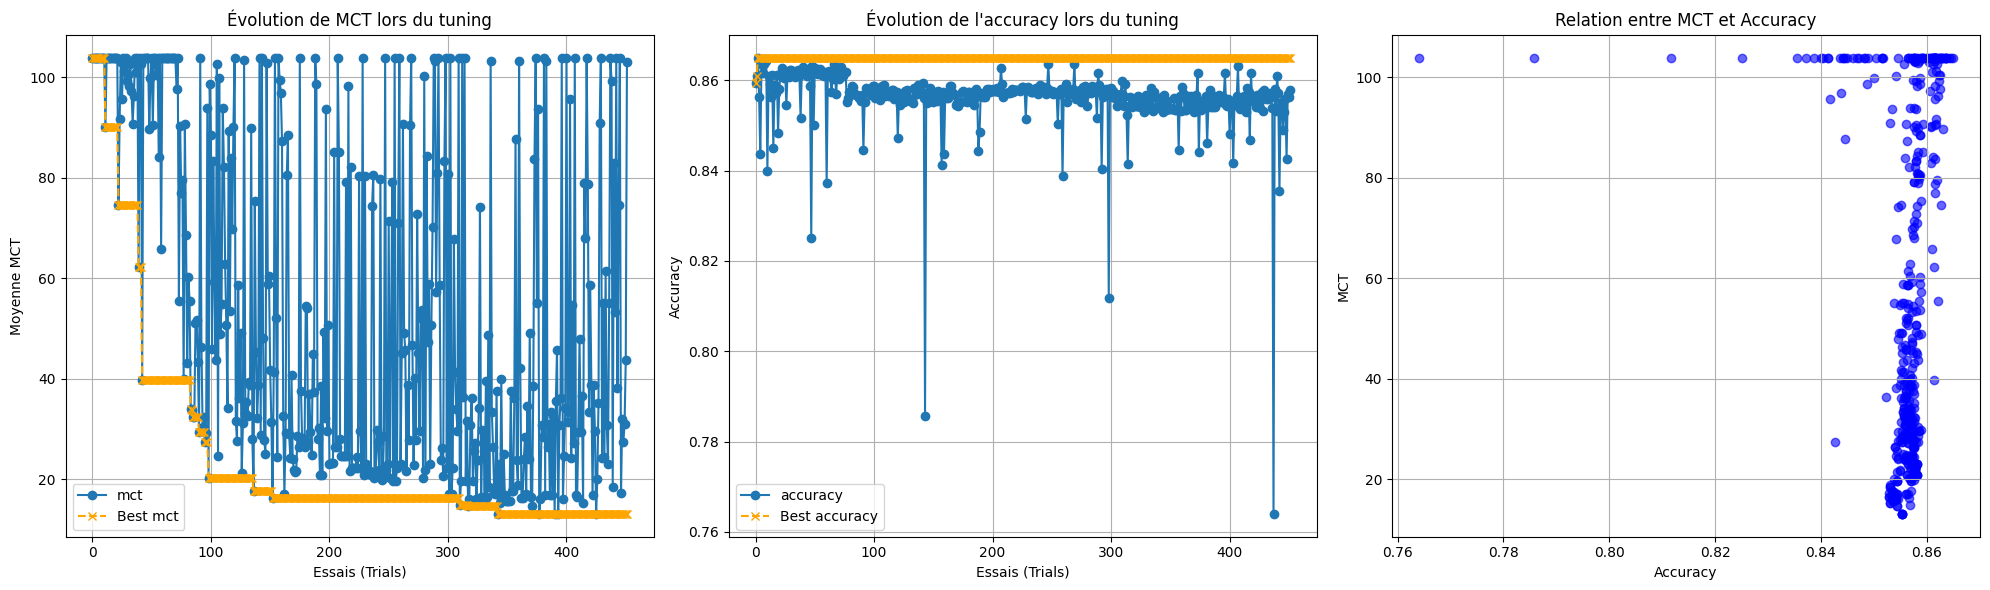

[I 2025-03-16 21:34:05,627] A new study created in memory with name: no-name-21bfb015-4d69-47a1-b2ac-1be785a3d3d6


Validation Performance for dataset 3:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       832
           1       0.85      0.56      0.68       588
           2       0.84      0.55      0.67       431
           3       0.85      0.45      0.59       329

   micro avg       0.81      0.63      0.71      2180
   macro avg       0.83      0.59      0.68      2180
weighted avg       0.82      0.63      0.70      2180
 samples avg       0.69      0.66      0.67      2180

(2000, 4) (2000, 4)
Accuracy: 0.86
Hamming Score: 0.86
calculated accuracy based on top probability only:0.7685
- - - saving - - -

Processing dataset 4...

Number of ressources 3...
Optimizing: Step 1, Remaining trials: 100


[I 2025-03-16 21:34:50,357] Trial 0 finished with value: -0.5937311700693727 and parameters: {'n_estimators': 144, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.5937311700693727.
[I 2025-03-16 21:36:24,633] Trial 1 finished with value: -0.5846861984417122 and parameters: {'n_estimators': 267, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: -0.5846861984417122.
[I 2025-03-16 21:37:59,423] Trial 2 finished with value: -0.5563095425542246 and parameters: {'n_estimators': 95, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 11, 'max_features': None}. Best is trial 2 with value: -0.5563095425542246.
[I 2025-03-16 21:39:29,981] Trial 3 finished with value: -0.5930474093856117 and parameters: {'n_estimators': 85, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 2 with value: -0.5563095

Optimizing: Step 2, Remaining trials: 100


[I 2025-03-17 00:48:31,422] Trial 100 finished with value: -0.5465352828032713 and parameters: {'n_estimators': 258, 'max_depth': 16, 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 58 with value: -0.5407757902585861.
[I 2025-03-17 00:50:40,969] Trial 101 finished with value: -0.544806370700889 and parameters: {'n_estimators': 282, 'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 58 with value: -0.5407757902585861.
[I 2025-03-17 00:52:52,367] Trial 102 finished with value: -0.540602413927923 and parameters: {'n_estimators': 278, 'max_depth': 15, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 102 with value: -0.540602413927923.
[I 2025-03-17 00:55:02,699] Trial 103 finished with value: -0.5421311023132888 and parameters: {'n_estimators': 288, 'max_depth': 15, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 102 with value: -0

...

Optimizing: Step 4, Remaining trials: 84


[I 2025-03-17 06:48:13,090] Trial 291 finished with value: -0.5345977145276093 and parameters: {'n_estimators': 175, 'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 231 with value: -0.5340976811920531.
[I 2025-03-17 06:50:07,730] Trial 292 finished with value: -0.539056048920994 and parameters: {'n_estimators': 185, 'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 231 with value: -0.5340976811920531.
[I 2025-03-17 06:52:02,536] Trial 293 finished with value: -0.5507508809201227 and parameters: {'n_estimators': 174, 'max_depth': 20, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 231 with value: -0.5340976811920531.
[I 2025-03-17 06:53:56,034] Trial 294 finished with value: -0.5376950577750061 and parameters: {'n_estimators': 179, 'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 231 with value

Optimizing: Step 5, Remaining trials: 77


[I 2025-03-17 09:20:14,395] Trial 375 finished with value: -0.5476066233485342 and parameters: {'n_estimators': 180, 'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 231 with value: -0.5340976811920531.
[I 2025-03-17 09:22:08,244] Trial 376 finished with value: -0.5398995757863205 and parameters: {'n_estimators': 176, 'max_depth': 19, 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 231 with value: -0.5340976811920531.
[I 2025-03-17 09:24:00,609] Trial 377 finished with value: -0.5544478399053666 and parameters: {'n_estimators': 164, 'max_depth': 20, 'min_samples_split': 13, 'min_samples_leaf': 13, 'max_features': None}. Best is trial 231 with value: -0.5340976811920531.
[I 2025-03-17 09:25:48,980] Trial 378 finished with value: -0.5410997156585448 and parameters: {'n_estimators': 168, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 231 with valu

Best Hyperparameters: {'n_estimators': 169, 'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': None}
Optimized Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.99      0.84      1458
           1       0.76      1.00      0.86      1524
           2       0.73      0.99      0.84      1448

   micro avg       0.74      0.99      0.85      4430
   macro avg       0.74      0.99      0.85      4430
weighted avg       0.74      0.99      0.85      4430
 samples avg       0.74      0.99      0.84      4430



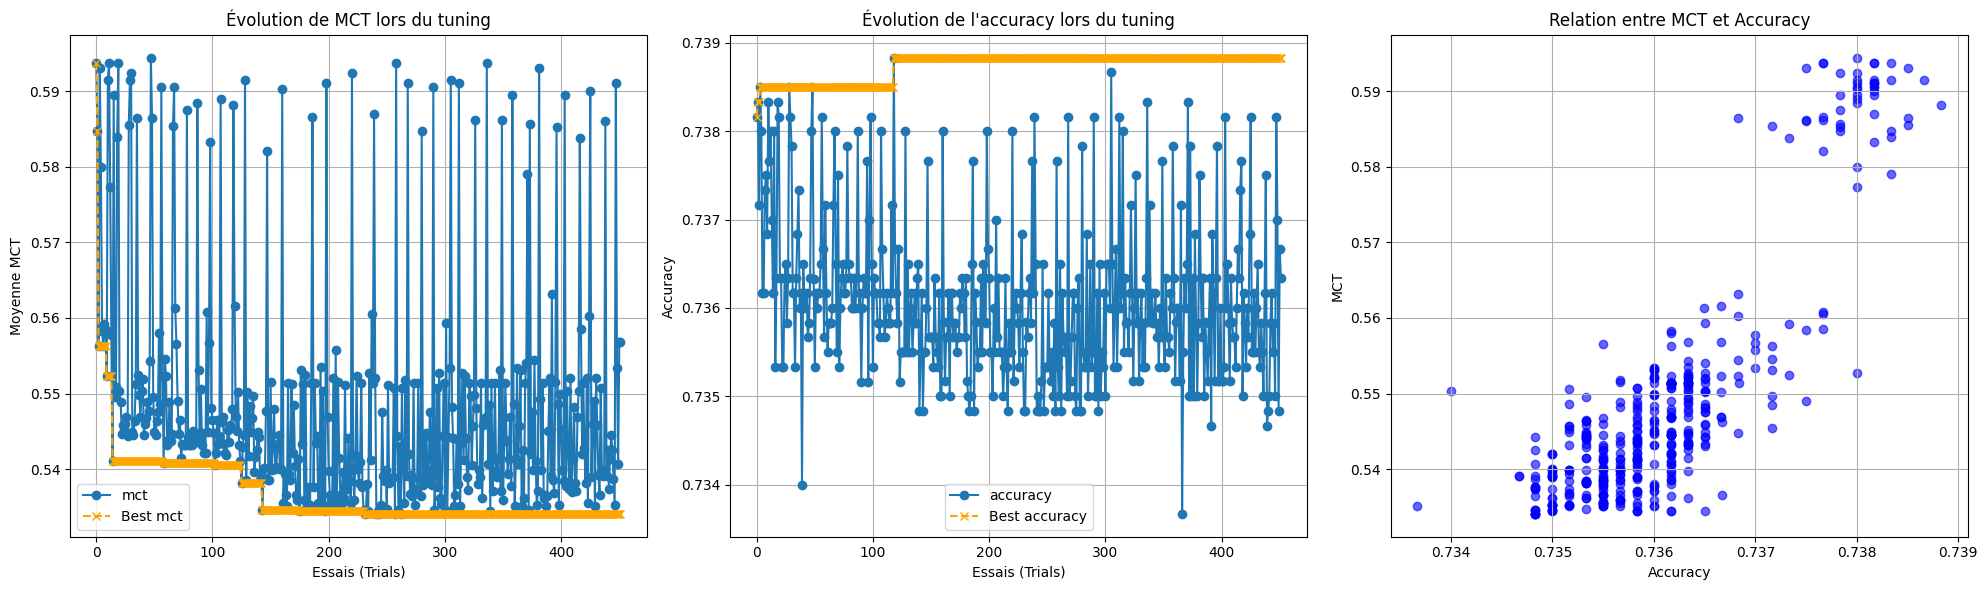

[I 2025-03-17 11:40:42,586] A new study created in memory with name: no-name-d5ae8e5f-f0d8-49d1-9d38-08122be299ab


Validation Performance for dataset 4:
              precision    recall  f1-score   support

           0       0.73      0.99      0.84      1458
           1       0.76      1.00      0.86      1524
           2       0.73      0.99      0.84      1448

   micro avg       0.74      0.99      0.85      4430
   macro avg       0.74      0.99      0.85      4430
weighted avg       0.74      0.99      0.85      4430
 samples avg       0.74      0.99      0.84      4430

(2000, 3) (2000, 3)
Accuracy: 0.7388333333333333
Hamming Score: 0.7388333333333333
calculated accuracy based on top probability only:0.7705
- - - saving - - -

Processing dataset 5...

Number of ressources 2...
Optimizing: Step 1, Remaining trials: 100


[I 2025-03-17 11:41:23,867] Trial 0 finished with value: -0.2758578741279978 and parameters: {'n_estimators': 144, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.2758578741279978.
[I 2025-03-17 11:42:50,424] Trial 1 finished with value: -0.28810996622102214 and parameters: {'n_estimators': 267, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.2758578741279978.
[I 2025-03-17 11:44:18,046] Trial 2 finished with value: -44.5022618012696 and parameters: {'n_estimators': 95, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 11, 'max_features': None}. Best is trial 0 with value: -0.2758578741279978.
[I 2025-03-17 11:45:42,084] Trial 3 finished with value: -0.29398719006808727 and parameters: {'n_estimators': 85, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.2758578

Optimizing: Step 2, Remaining trials: 100


[I 2025-03-17 14:07:24,305] Trial 100 finished with value: -0.25576726232103414 and parameters: {'n_estimators': 256, 'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 24 with value: -0.23052801334840614.
[I 2025-03-17 14:08:52,501] Trial 101 finished with value: -0.23323037575950348 and parameters: {'n_estimators': 242, 'max_depth': 14, 'min_samples_split': 15, 'min_samples_leaf': 15, 'max_features': 'log2'}. Best is trial 24 with value: -0.23052801334840614.
[I 2025-03-17 14:10:20,124] Trial 102 finished with value: -0.23797708845520155 and parameters: {'n_estimators': 241, 'max_depth': 14, 'min_samples_split': 15, 'min_samples_leaf': 15, 'max_features': 'log2'}. Best is trial 24 with value: -0.23052801334840614.
[I 2025-03-17 14:11:47,668] Trial 103 finished with value: -0.2544088566338864 and parameters: {'n_estimators': 240, 'max_depth': 13, 'min_samples_split': 16, 'min_samples_leaf': 15, 'max_features': 'log2'}. Best is trial

...

Optimizing: Step 4, Remaining trials: 84


[I 2025-03-17 18:47:00,824] Trial 291 finished with value: -0.24234754990009016 and parameters: {'n_estimators': 258, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 15, 'max_features': 'log2'}. Best is trial 245 with value: -0.22540357148137677.
[I 2025-03-17 18:48:28,783] Trial 292 finished with value: -0.27405295641822836 and parameters: {'n_estimators': 241, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 14, 'max_features': 'log2'}. Best is trial 245 with value: -0.22540357148137677.
[I 2025-03-17 18:49:56,448] Trial 293 finished with value: -0.26607205365762865 and parameters: {'n_estimators': 249, 'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 245 with value: -0.22540357148137677.
[I 2025-03-17 18:51:24,446] Trial 294 finished with value: -0.2408334894748046 and parameters: {'n_estimators': 254, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 15, 'max_features': 'log2'}. Best is trial

Optimizing: Step 5, Remaining trials: 77


[I 2025-03-17 20:50:51,818] Trial 375 finished with value: -0.29682724210359257 and parameters: {'n_estimators': 246, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 245 with value: -0.22540357148137677.
[I 2025-03-17 20:52:19,387] Trial 376 finished with value: -0.2673404478310945 and parameters: {'n_estimators': 239, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 14, 'max_features': 'log2'}. Best is trial 245 with value: -0.22540357148137677.
[I 2025-03-17 20:53:47,150] Trial 377 finished with value: -0.2699158611236544 and parameters: {'n_estimators': 257, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 245 with value: -0.22540357148137677.
[I 2025-03-17 20:55:13,461] Trial 378 finished with value: -0.23443420342481808 and parameters: {'n_estimators': 178, 'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 15, 'max_features': 'log2'}. Best is trial

Best Hyperparameters: {'n_estimators': 247, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 15, 'max_features': 'log2'}
Optimized Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       829
           1       0.84      0.92      0.88      1214

   micro avg       0.85      0.84      0.84      2043
   macro avg       0.85      0.82      0.83      2043
weighted avg       0.85      0.84      0.84      2043
 samples avg       0.85      0.85      0.85      2043



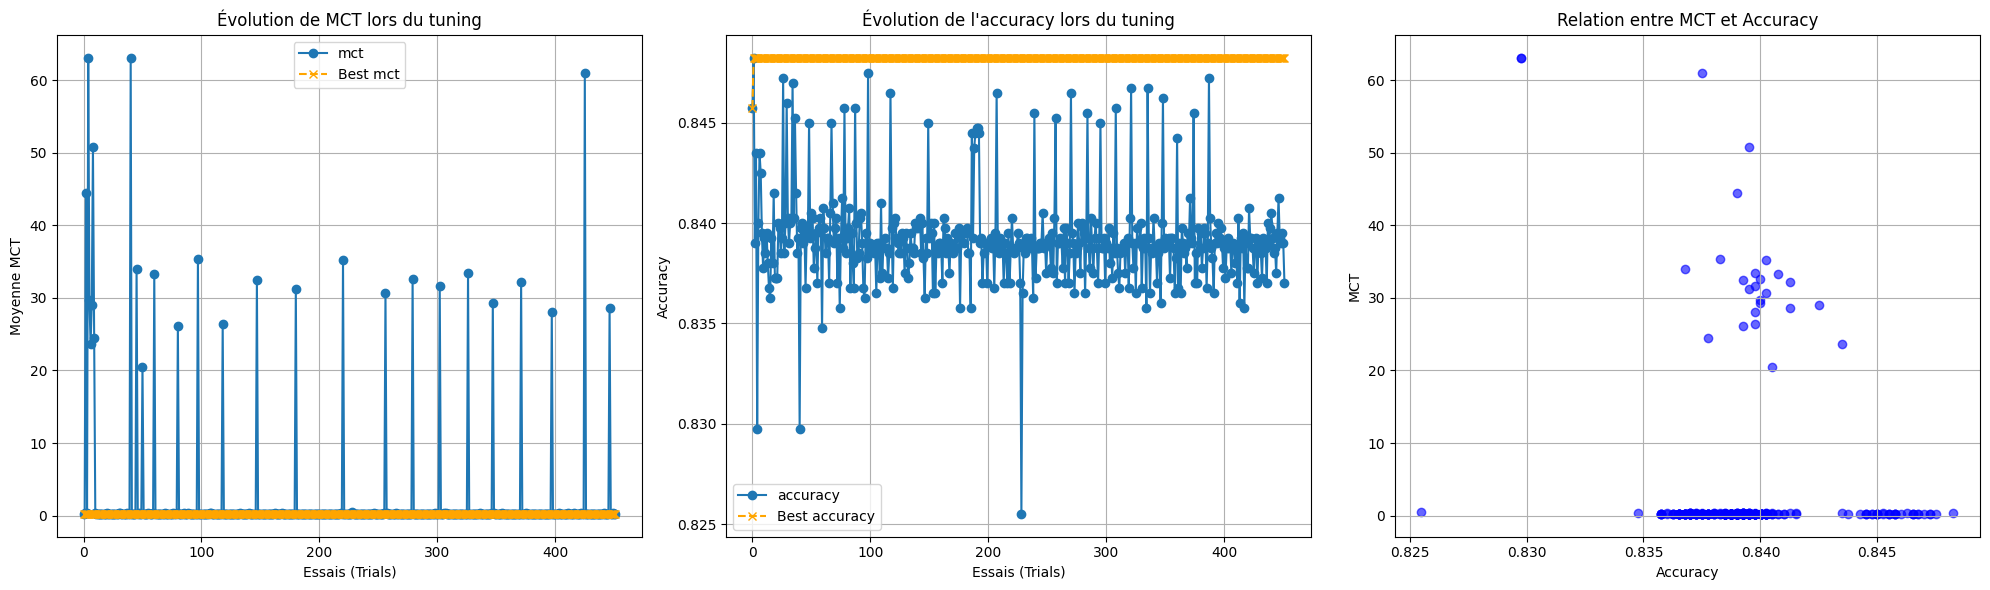

Validation Performance for dataset 5:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       829
           1       0.84      0.92      0.88      1214

   micro avg       0.85      0.84      0.84      2043
   macro avg       0.85      0.82      0.83      2043
weighted avg       0.85      0.84      0.84      2043
 samples avg       0.85      0.85      0.85      2043

(2000, 2) (2000, 2)
Accuracy: 0.841
Hamming Score: 0.841
calculated accuracy based on top probability only:0.85
- - - saving - - -


In [ ]:
#training (les deux datasets le meme code, changer juste point rouge)

nn_models, rf_models, xgb_models= [], [], []
model_type = "rf" # "rf" "xgboost" "nn"

c=0
for i, (train_df, test_df) in enumerate(zip(dfs_train, dfs_test)):
    c+=1
    print(f"\nProcessing dataset {i+1}...")
    nb_classes = len([col for col in train_df.columns if col.startswith("Selected")])
    print(f"\nNumber of ressources {nb_classes}...")

    X_train, y_train = train_df.iloc[:, :-nb_classes], train_df.iloc[:, -nb_classes:].map(lambda x: 1 if x > 0 else 0)
    X_test, y_test = test_df.iloc[:, :-nb_classes], test_df.iloc[:, -nb_classes:].map(lambda x: 1 if x > 0 else 0)

    if model_type == "rf":
        model = train_random_forest_with_optuna(X_train, y_train, X_test, y_test, scalers[c-1], max_trials = 500, alpha= 100, beta = 0.1, random_seed=RANDOM_SEED, scenarios_test=test_split_scenarios,cell=c)
    elif model_type == "xgboost":
        model = train_xgboost_with_optuna(X_train, y_train, X_test, y_test, random_seed=RANDOM_SEED)
    elif model_type == "nn":
        model = train_neural_network_with_optuna(X_train, y_train, X_test, y_test, max_trials = 500, alpha= 100, beta = 0.1, epochs = 20, batch_size = 32, random_seed=RANDOM_SEED)
    else:
        raise ValueError("Invalid model type specified. Choose 'rf', 'xgboost', or 'nn'")

    predictions_test = model[0].predict(X_test)
    print(f"Validation Performance for dataset {i+1}:")
    if model_type == "nn":
        predictions_test = np.round(predictions_test)

    print(classification_report(y_test, predictions_test))
    print(y_test.shape, predictions_test.shape)
    accuracy = np.mean(y_test == predictions_test)
    print(f"Accuracy: {accuracy}")
    print(f"Hamming Score: {1 - hamming_loss(y_test, predictions_test)}")
    
    if model_type == "nn":
        predicted = np.argmax(model[0].predict(X_test), axis=1)
    elif model_type == "rf":
        predicted = np.argmax(np.column_stack([model[0].predict_proba(X_test)[i][:,1] for i in range(len(model[0].predict_proba(X_test)))]), axis=1)
    else :
        predicted = np.argmax(model[0].predict_proba(X_test), axis=1)    
    count = 0
    for i in range(predicted.shape[0]):
        ress_choice = predicted[i] 
        if y_test.iloc[i, ress_choice] == 1:  
            count += 1
    print(f"calculated accuracy based on top probability only:{count/predicted.shape[0]}")

    if model_type == "nn":
        nn_models.append(model[0])
        model[0].save(f"generated_models/multiclass/K0/models_cell{c}/dense_with_gauss.keras")
    elif model_type == "rf":
        print("- - - saving - - -")
        rf_models.append(model[0])
        with open(f"generated_models/multiclass_added_min/G/models_cell{c}/standard_RandomForest.pkl", 'wb') as file: #change G for K0
            pickle.dump(model[0], file)
    elif model_type == "xgboost":
        xgb_models.append(model[0])
        with open(f"generated_models/multiclass/K0/models_cell{c}/GradientBoostingClassifier.pkl", 'wb') as file:
            pickle.dump(model[0], file)


In [ ]:
models, scalers, mc_models, mc_scalers = [], [], [], []
for i in range(1,4):
    with open(f"generated_models/multiclass_added_min/K0/models_cell{i}/standard_RandomForest.pkl", 'rb') as f:
        mc_models.append(pickle.load(f))

    with open(f"generated_models/multiclass_added_min/K0/models_cell{i}/scaler.pkl", 'rb') as f:
        mc_scalers.append(pickle.load(f))

In [2]:
models, scalers, mc_models, mc_scalers = [], [], [], []
for i in range(1,6):
    with open(f"generated_models/multiclass_added_min/G/models_cell{i}/standard_RandomForest.pkl", 'rb') as f:
        mc_models.append(pickle.load(f))

    with open(f"generated_models/multiclass_added_min/G/models_cell{i}/scaler.pkl", 'rb') as f:
        mc_scalers.append(pickle.load(f))

In [24]:
X_train, y_train = dfs_train[2].iloc[:, :-4], dfs_train[2].iloc[:, -4:].map(lambda x: 1 if x > 0 else 0)

In [67]:
np.unique(mc_models[2].predict(X_train).sum(axis=1))
# je me rend compte que j'ai fait une erreur, je ne prend pas la top probabilité, je prend juste le premier 1 n'est ce pas ?
np.argmax([[0,1,1,0]], axis=1)[0]

1

In [ ]:
scenarios_path = f"scenarios/K0"
solution_path = f"solution/K0_best//"

with open(f'fms/3C7R5F.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
s = sys.systeme(dic)
results = np.zeros((0,4))
reference_results = np.zeros((0,4))

for f in os.listdir(scenarios_path):
    print(f"{f.split(".")[0]}\t:\t", end = "")
    if int(f.split(".")[0][1:]) not in test_split_scenarios:
        print("dans les scenarios d'entrainement")
        continue
    df = pd.DataFrame(np.nan_to_num(pd.read_csv(f"{scenarios_path}/"+f,header=None, index_col=None, sep=";"), nan=0)).astype(int)
    own_sol_path_list = [file for file in os.listdir(solution_path) if file.split(".")[0][-len(f.split(".")[0]):] == f.split(".")[0]]
    
    sol_path = own_sol_path_list[0]
    sol = pd.read_csv(solution_path+sol_path, sep=";", index_col=None, header=None).iloc[:,1:-1]

    dyn_allocs = [Allocation.DynamicAllocator(s, models[i], scalers[i], keep_cols=None, to_categorical=True) for i in range(3)]
    dyn_mc_allocs = [Allocation.DynamicAllocator(s, mc_models[i], mc_scalers[i], keep_cols=None, to_categorical=True) for i in range(3)]

    static_allocators = [Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol)]
    
    allocators = [static_allocators[0],
                  #dyn_mc_allocs[0], 
                  static_allocators[1], 
                  #dyn_mc_allocs[1], 
                  #static_allocators[2], 
                  dyn_mc_allocs[2]
                  ]
    
    sim = simulation(system=s, scenario=df, allocators=allocators)
    results = np.vstack((results, np.array([f.split(".")[0], sim.average_flowtime(), sim.mean_completion_time(), sim.total_decision_times()])))

    sim_ref = simulation(system=s, scenario=df, allocators=static_allocators)
    reference_results = np.vstack((reference_results, np.array([f.split(".")[0], sim_ref.average_flowtime(), sim_ref.mean_completion_time(), sim_ref.total_decision_times()])))

    print(f"ended with mct : {sim.mean_completion_time()} while the reference mct is {sim_ref.mean_completion_time()}")

df = pd.DataFrame(results, columns=["scenario", "avg_flowtime", "mct", "decision_time"])
df['num'] = df['scenario'].str.extract(r'(\d+)').astype(int)
df_sorted = df.sort_values(by='num').drop(columns='num').reset_index(drop=True).mct.astype(float)

df_ref = pd.DataFrame(reference_results, columns=["scenario", "avg_flowtime", "mct", "decision_time"])
df_ref['num'] = df['scenario'].str.extract(r'(\d+)').astype(int)
ref = df_ref.sort_values(by='num').drop(columns='num').reset_index(drop=True).mct.astype(float)

print(f"gap {"ag" if isinstance(allocators[0], Allocation.StaticAllocator) else "m"} {"ag" if isinstance(allocators[1], Allocation.StaticAllocator) else "m"} {"ag" if isinstance(allocators[2], Allocation.StaticAllocator) else "m"} {(100*(df_sorted - ref)/ref).mean()} %")

In [5]:
scenarios_path = f"scenarios/g3"
solution_path = f"solution/g3_best//"

with open(f'fms/5C14R5F.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
s = sys.systeme(dic)
results = np.zeros((0,4))
reference_results = np.zeros((0,4))

for f in os.listdir(scenarios_path):
    print(f"{f.split(".")[0]}\t:\t", end = "")
    df = pd.DataFrame(np.nan_to_num(pd.read_csv(f"{scenarios_path}/"+f,header=None, index_col=None, sep=";"), nan=0)).astype(int)
    own_sol_path_list = [file for file in os.listdir(solution_path) if file.split(".")[0][-len(f.split(".")[0]):] == f.split(".")[0]]
    
    sol_path = own_sol_path_list[0]
    sol = pd.read_csv(solution_path+sol_path, sep=";", index_col=None, header=None).iloc[:,1:-1]

    dyn_mc_allocs = [Allocation.DynamicAllocator(s, mc_models[i], mc_scalers[i], keep_cols=None, to_categorical=True) for i in range(5)]

    static_allocators = [Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol), Allocation.StaticAllocator(s, sol)]
    
    allocators = [#static_allocators[0],
                  dyn_mc_allocs[0], 
                  
                  #static_allocators[1], 
                  dyn_mc_allocs[1], 
                  
                  #static_allocators[2], 
                  dyn_mc_allocs[2],
                  
                  #static_allocators[3], 
                  dyn_mc_allocs[3], 
                  
                  #static_allocators[4], 
                  dyn_mc_allocs[4],
                  ]
    
    sim = simulation(system=s, scenario=df, allocators=allocators)
    results = np.vstack((results, np.array([f.split(".")[0], sim.average_flowtime(), sim.mean_completion_time(), sim.total_decision_times()])))

    sim_ref = simulation(system=s, scenario=df, allocators=static_allocators)
    reference_results = np.vstack((reference_results, np.array([f.split(".")[0], sim_ref.average_flowtime(), sim_ref.mean_completion_time(), sim_ref.total_decision_times()])))

    sim.gantt_multi(f"added_{f.split(".")[0]}_num")
    sim_ref.gantt_multi(f"reference_{f.split(".")[0]}_num")

    print(f"ended with mct : {sim.mean_completion_time()} while the reference mct is {sim_ref.mean_completion_time()}")

df = pd.DataFrame(results, columns=["scenario", "avg_flowtime", "mct", "decision_time"])
df['num'] = df['scenario'].str.extract(r'(\d+)').astype(int)
df_sorted = df.sort_values(by='num').drop(columns='num').reset_index(drop=True).mct.astype(float)

df_ref = pd.DataFrame(reference_results, columns=["scenario", "avg_flowtime", "mct", "decision_time"])
df_ref['num'] = df['scenario'].str.extract(r'(\d+)').astype(int)
ref = df_ref.sort_values(by='num').drop(columns='num').reset_index(drop=True).mct.astype(float)

print(f"gap {"ag" if isinstance(allocators[0], Allocation.StaticAllocator) else "m"} {"ag" if isinstance(allocators[1], Allocation.StaticAllocator) else "m"} {"ag" if isinstance(allocators[2], Allocation.StaticAllocator) else "m"} {"ag" if isinstance(allocators[3], Allocation.StaticAllocator) else "m"} {"ag" if isinstance(allocators[4], Allocation.StaticAllocator) else "m"} {(100*(df_sorted - ref)/ref).mean()} %")

ended with mct : 408.14 while the reference mct is 286.49 430250
ended with mct : 394.51 while the reference mct is 288.39 340 250
ended with mct : 406.01 while the reference mct is 287.16 380 250
ended with mct : 413.61 while the reference mct is 292.5: 360 250
ended with mct : 393.53 while the reference mct is 284.44 550 250
ended with mct : 426.63 while the reference mct is 299.98 650 250
ended with mct : 433.69 while the reference mct is 295.9: 780 250
ended with mct : 403.97 while the reference mct is 289.13 360 250
ended with mct : 403.01 while the reference mct is 277.75 660 250
ended with mct : 425.65 while the reference mct is 295.09 280 250
ended with mct : 418.96 while the reference mct is 310.29 880 250
ended with mct : 428.09 while the reference mct is 308.14 109250
ended with mct : 443.51 while the reference mct is 289.43 360 250
ended with mct : 424.1 while the reference mct is 299.58: 780250
ended with mct : 429.32 while the reference mct is 293.99 700250
ended with mct

<Figure size 640x480 with 0 Axes>